In [1]:
import torch
from torch import nn
import numpy as np
from collections import deque
import time

In [5]:
#linear model with one hiden layer


class linear_model_1(nn.Module):
  def __init__(self, input_features: int, hidden_units: int, output_features: int):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
      nn.Linear(in_features=input_features, out_features=hidden_units),
      nn.Linear(in_features=hidden_units, out_features=hidden_units),
      nn.Linear(in_features=hidden_units, out_features=output_features)
  )
  def forward(self, x):
    return self.linear_layer_stack(x)

In [6]:
##linear model with two hiden layers

class linear_model_2(nn.Module):
  def __init__(self, input_features: int, hidden_units: int, output_features: int):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
      nn.Linear(in_features=input_features, out_features=hidden_units),
      nn.Linear(in_features=hidden_units, out_features=hidden_units),
      nn.Linear(in_features=hidden_units, out_features=hidden_units),
      nn.Linear(in_features=hidden_units, out_features=output_features)
  )
  def forward(self, x):
    return self.linear_layer_stack(x)

In [7]:
#non-linear model with one hiden layer


class non_linear_model_1(nn.Module):
  def __init__(self, input_features: int, hidden_units: int, output_features: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
      nn.Linear(in_features=input_features, out_features=hidden_units),
      nn.ReLU(),
      nn.Linear(in_features=hidden_units, out_features=hidden_units),
      nn.ReLU(),
      nn.Linear(in_features=hidden_units, out_features=output_features)
  )
  def forward(self, x):
    return self.layer_stack(x)

In [8]:
#non-linear model with two hiden layers

class non_linear_model_2(nn.Module):
  def __init__(self, input_features: int, hidden_units: int, output_features: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
      nn.Linear(in_features=input_features, out_features=hidden_units),
      nn.ReLU(),
      nn.Linear(in_features=hidden_units, out_features=hidden_units),
      nn.ReLU(),
      nn.Linear(in_features=hidden_units, out_features=hidden_units),
      nn.ReLU(),
      nn.Linear(in_features=hidden_units, out_features=output_features)
  )
  def forward(self, x):
    return self.layer_stack(x)

In [9]:
#Accuracy function:


def acc_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()

  accuracy = (correct / len(y_pred)) * 100

  return accuracy


In [10]:
def training_step(model, x_train_data, y_train_data, loss_fn, optimizer, acc_fn = acc_fn):
  model.train()


  y_logits_train = model(x_train_data)
  y_train_pred = torch.round(torch.sigmoid(y_logits_train))


  loss = loss_fn(y_logits_train, y_train_data)
  acc = acc_fn(y_train_data, y_train_pred)

  optimizer.zero_grad()


  loss.backward()


  optimizer.step()

  return loss.item(), acc

In [11]:
def testing_step(model, x_test_data, y_test_data, loss_fn, acc_fn = acc_fn):
  start_time = time.perf_counter()
  model.eval()

  y_logits_test = model(x_test_data)
  y_test_pred = torch.round(torch.sigmoid(y_logits_test))

  test_loss = loss_fn(y_logits_test, y_test_data)
  test_acc = acc_fn(y_test_data, y_test_pred)

  end_time = time.perf_counter()
  total_time = end_time - start_time

  return test_loss.item(), test_acc, total_time

In [3]:
from sklearn.model_selection import train_test_split

data = np.load("fall_dataset.npz")
data_X = torch.tensor(data["X"])
data_y = torch.tensor(data["y"], dtype=torch.float32)

In [13]:
#turn dataset into test and train lists
x_train, x_test, y_train, y_test = train_test_split(data_X, data_y, test_size=0.2, random_state=42)

x_train = torch.tensor(x_train)
x_test = torch.tensor(x_test)
y_train = torch.unsqueeze(torch.tensor(y_train), dim = 1)
y_test = torch.unsqueeze(torch.tensor(y_test), dim = 1)


C:\Users\vince\AppData\Local\Temp\ipykernel_18044\1811110932.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train = torch.tensor(x_train)
C:\Users\vince\AppData\Local\Temp\ipykernel_18044\1811110932.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test = torch.tensor(x_test)
C:\Users\vince\AppData\Local\Temp\ipykernel_18044\1811110932.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.unsqueeze(torch.tensor(y_train), dim = 1)
C:\Users\vince\AppData\Local\Temp\ipykernel_18044\1811110932.py:7: UserWarning: To co

In [15]:
def training_and_testing_loops(epochs, model, Loss_fn, Optimizer, x_train = x_train, y_train = y_train, x_test = x_test, y_test = y_test):

  lowest_loss = deque([5000], maxlen= 1)
  lowest_loss_epoch = deque([0], maxlen= 1)
  lowest_loss_accuracy = deque([0], maxlen= 1)

  train_losses = []
  test_losses = []
  run_times = []

  for epoch in range(epochs):
    train_loss, train_acc = training_step(model, x_train, y_train, Loss_fn, Optimizer)
    test_loss, test_acc, test_time_duration = testing_step(model, x_test, y_test, Loss_fn) # Get time duration

    run_times.append(test_time_duration)

    lowest_loss, lowest_loss_epoch, lowest_loss_accuracy = lowest_test_loss(test_loss, lowest_loss, lowest_loss_epoch, epoch, lowest_loss_accuracy, test_acc)

    if epoch % 10 == 0:
      train_losses.append(train_loss)
      test_losses.append(test_loss)

  plot_loss_curves(epochs, train_losses, test_losses)
  print(f'Lowest test loss was {lowest_loss[0]:.5f} with an accuracy of {lowest_loss_accuracy[0]:.2f}% at epoch {lowest_loss_epoch[0]}')
  print(f'Average test time per epoch: {sum(run_times) / len(run_times):.5f} seconds')
  print(f'final stats are: loss:{test_loss:.5f} | accuracy: {test_acc:.2f}')

In [2]:
import matplotlib.pyplot as plt

def plot_loss_curves(epochs, train_losses, test_losses):
  plt.figure(figsize=(10, 7))
  plt.plot(range(0,epochs,10), train_losses, label="Training Loss")
  plt.plot(range(0,epochs,10), test_losses, label="Test Loss")
  plt.title("Loss Curves")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

In [17]:
def lowest_test_loss(test_loss, lowest_loss, lowest_loss_epoch, epoch, lowest_loss_accuracy, test_acc):
  if test_loss < lowest_loss[0]:
    lowest_loss.append(test_loss)
    lowest_loss_epoch.append(epoch)
    lowest_loss_accuracy.append(test_acc)

  return lowest_loss, lowest_loss_epoch, lowest_loss_accuracy

In [18]:
# @title model_0 declaration
model_0 = linear_model_1(720, 16, 1)

Optimizer = torch.optim.SGD(model_0.parameters(), lr = 0.001)

Loss_fn = nn.BCEWithLogitsLoss()

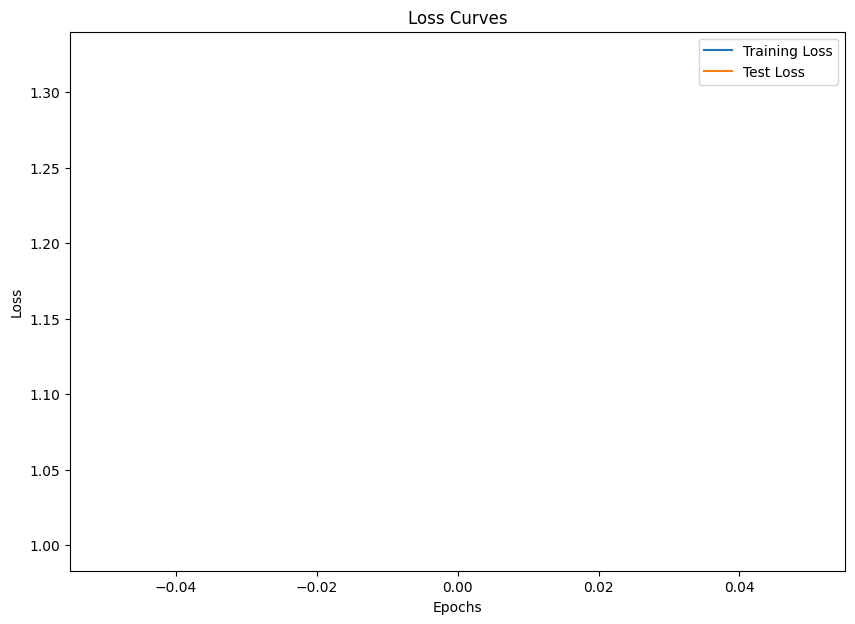

Lowest test loss was 0.99924 with an accuracy of 35.71% at epoch 0
Average test time per epoch: 0.03474 seconds
final stats are: loss:0.99924 | accuracy: 35.71


In [ ]:
# @title model_0 train/test
training_and_testing_loops(5001, model_0, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_1 declaration
# model_1 = linear_model_1(720, 32, 1)

# Optimizer = torch.optim.SGD(model_1.parameters(), lr = 0.001)

# Loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
# @title model_1 train/test
# training_and_testing_loops(5001, model_1, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_2 declaration
# model_2 = linear_model_2(720, 16, 1)

# Optimizer = torch.optim.SGD(model_2.parameters(), lr = 0.001)

# Loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
# @title model_2 train/test
# training_and_testing_loops(5001, model_2, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_3 declaration
# model_3 = linear_model_2(720, 32, 1)

# Optimizer = torch.optim.SGD(model_3.parameters(), lr = 0.001)

# Loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
# @title model_3 train/test
# training_and_testing_loops(5001, model_3, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_4 declaration
# model_4 = non_linear_model_1(720, 16, 1)

# Optimizer = torch.optim.SGD(model_4.parameters(), lr = 0.001)

# Loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
# @title model_4 train/test
# training_and_testing_loops(5001, model_4, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_5 declaration
# model_5 = non_linear_model_1(720, 32, 1)

# Optimizer = torch.optim.SGD(model_5.parameters(), lr = 0.001)

# Loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
# @title model_5 train/test
# training_and_testing_loops(5001, model_5, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_6 declaration
# model_6 = non_linear_model_2(720, 16, 1)

# Optimizer = torch.optim.SGD(model_6.parameters(), lr = 0.001)

# Loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
# @title model_6 train/test
# training_and_testing_loops(5001, model_6, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_7 declaration
# model_7 = non_linear_model_2(720, 32, 1)

# Optimizer = torch.optim.SGD(model_7.parameters(), lr = 0.001)

# Loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
# @title model_7 train/test
# training_and_testing_loops(5001, model_7, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_8 declaration
# model_8 = linear_model_1(720, 16, 1)

# Optimizer = torch.optim.Adam(model_8.parameters(), lr = 0.001)

# Loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
# @title model_8 train/test
# training_and_testing_loops(5001, model_8, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_9 declaration
# model_9 = linear_model_1(720, 32, 1)

# Optimizer = torch.optim.Adam(model_9.parameters(), lr = 0.001)

# Loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
# @title model_9 train/test
# training_and_testing_loops(5001, model_9, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_10 declaration
# model_10 = linear_model_2(720, 16, 1)

# Optimizer = torch.optim.Adam(model_10.parameters(), lr = 0.001)

# Loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
# @title model_10 train/test
# training_and_testing_loops(5001, model_10, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_11 declaration
# model_11 = linear_model_2(720, 32, 1)

# Optimizer = torch.optim.Adam(model_11.parameters(), lr = 0.001)

# Loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
# @title model_11 train/test
# training_and_testing_loops(5001, model_11, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_12 declaration
# model_12 = non_linear_model_1(720, 16, 1)

# Optimizer = torch.optim.Adam(model_12.parameters(), lr = 0.001)

# Loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
# @title model_12 train/test
# training_and_testing_loops(5001, model_12, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_13 declaration
# model_13 = non_linear_model_1(720, 32, 1)

# Optimizer = torch.optim.Adam(model_13.parameters(), lr = 0.001)

# Loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
# @title model_13 train/test
# training_and_testing_loops(5001, model_13, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_14 declaration
# model_14 = non_linear_model_2(720, 16, 1)

# Optimizer = torch.optim.Adam(model_14.parameters(), lr = 0.001)

# Loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
# @title model_14 train/test
# training_and_testing_loops(5001, model_14, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_15 declaration
# model_15 = non_linear_model_2(720, 32, 1)

# Optimizer = torch.optim.Adam(model_15.parameters(), lr = 0.001)

# Loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
# @title model_15 train/test
# training_and_testing_loops(5001, model_15, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_16 declaration
# model_16 = linear_model_1(720, 16, 1)

# Optimizer = torch.optim.SGD(model_16.parameters(), lr = 0.001)

# Loss_fn = nn.L1Loss()

In [ ]:
# @title model_16 train/test
# training_and_testing_loops(5001, model_16, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_17 declaration
# model_17 = linear_model_1(720, 32, 1)

# Optimizer = torch.optim.SGD(model_17.parameters(), lr = 0.001)

# Loss_fn = nn.L1Loss()

In [ ]:
# @title model_17 train/test
# training_and_testing_loops(5001, model_17, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_18 declaration
# model_18 = linear_model_2(720, 16, 1)

# Optimizer = torch.optim.SGD(model_18.parameters(), lr = 0.001)

# Loss_fn = nn.L1Loss()

In [ ]:
# @title model_18 train/test
# training_and_testing_loops(5001, model_18, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_19 declaration
# model_19 = linear_model_2(720, 32, 1)

# Optimizer = torch.optim.SGD(model_19.parameters(), lr = 0.001)

# Loss_fn = nn.L1Loss()

In [ ]:
# @title model_19 train/test
# training_and_testing_loops(5001, model_19, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_20 declaration
# model_20 = non_linear_model_1(720, 16, 1)

# Optimizer = torch.optim.SGD(model_20.parameters(), lr = 0.001)

# Loss_fn = nn.L1Loss()

In [ ]:
# @title model_20 train/test
# training_and_testing_loops(5001, model_20, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_21 declaration
# model_21 = non_linear_model_1(720, 32, 1)

# Optimizer = torch.optim.SGD(model_21.parameters(), lr = 0.001)

# Loss_fn = nn.L1Loss()

In [ ]:
# @title model_21 train/test
# training_and_testing_loops(5001, model_21, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_22 declaration
# model_22 = non_linear_model_2(720, 16, 1)

# Optimizer = torch.optim.SGD(model_22.parameters(), lr = 0.001)

# Loss_fn = nn.L1Loss()

In [ ]:
# @title model_22 train/test
# training_and_testing_loops(5001, model_22, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_23 declaration
# model_23 = non_linear_model_2(720, 32, 1)

# Optimizer = torch.optim.SGD(model_23.parameters(), lr = 0.001)

# Loss_fn = nn.L1Loss()

In [ ]:
# @title model_23 train/test
# training_and_testing_loops(5001, model_23, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_24 declaration
# model_24 = linear_model_1(720, 16, 1)

# Optimizer = torch.optim.Adam(model_24.parameters(), lr = 0.001)

# Loss_fn = nn.L1Loss()

In [ ]:
# @title model_24 train/test
# training_and_testing_loops(5001, model_24, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_25 declaration
# model_25 = linear_model_1(720, 32, 1)

# Optimizer = torch.optim.Adam(model_25.parameters(), lr = 0.001)

# Loss_fn = nn.L1Loss()

In [ ]:
# @title model_25 train/test
# training_and_testing_loops(5001, model_25, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_26 declaration
# model_26 = linear_model_2(720, 16, 1)

# Optimizer = torch.optim.Adam(model_26.parameters(), lr = 0.001)

# Loss_fn = nn.L1Loss()

In [ ]:
# @title model_26 train/test
# training_and_testing_loops(5001, model_26, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_27 declaration
# model_27 = linear_model_2(720, 32, 1)

# Optimizer = torch.optim.Adam(model_27.parameters(), lr = 0.001)

# Loss_fn = nn.L1Loss()

In [ ]:
# @title model_27 train/test
# training_and_testing_loops(5001, model_27, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_28 declaration
# model_28 = non_linear_model_1(720, 16, 1)

# Optimizer = torch.optim.Adam(model_28.parameters(), lr = 0.001)

# Loss_fn = nn.L1Loss()

In [ ]:
# @title model_28 train/test
# training_and_testing_loops(5001, model_28, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_29 declaration
# model_29 = non_linear_model_1(720, 32, 1)

# Optimizer = torch.optim.Adam(model_29.parameters(), lr = 0.001)

# Loss_fn = nn.L1Loss()

In [ ]:
# @title model_29 train/test
# training_and_testing_loops(5001, model_29, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_30 declaration
# model_30 = non_linear_model_2(720, 16, 1)

# Optimizer = torch.optim.Adam(model_30.parameters(), lr = 0.001)

# Loss_fn = nn.L1Loss()

In [ ]:
# @title model_30 train/test
# training_and_testing_loops(5001, model_30, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
# @title model_31 declaration
# model_31 = non_linear_model_2(720, 32, 1)

# Optimizer = torch.optim.Adam(model_31.parameters(), lr = 0.001)

# Loss_fn = nn.L1Loss()

In [ ]:
# @title model_31 train/test
# training_and_testing_loops(5001, model_31, Optimizer = Optimizer, Loss_fn = Loss_fn)

In [ ]:
from pathlib import Path
# MODEL_PATH = Path("Models")
# MODEL_PATH.mkdir(parents=True, exist_ok=True)

# MODEL_NAME = "fall_model.pth"

# MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# torch.save(obj=model_0.state_dict(),
#           f=MODEL_SAVE_PATH)